# **PREDIKSI HARGA EMAS MENGGUNAKAN LSTM DAN GRU**

# **1. Import Library**

In [ ]:
!pip install keras-tuner

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

<ipython-input-2-a271dc7a49df>:14: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


# **2. Read Dataset**

**A. Data Suku Bunga Indonesia (Sumber: [Bank Indonesia](https://www.bi.go.id/id/statistik/indikator/BI-Rate.aspx)**)

In [ ]:
#membaca dataset
suku_bunga = pd.read_excel('/content/suku bunga.xlsx')

#menampilkan dataset
suku_bunga

,NO,Tanggal,BI-7Day-RR
0,1,16 Oktober 2024,6.00 %
1,2,18 September 2024,6.00 %
2,3,21 Agustus 2024,6.25 %
3,4,17 Juli 2024,6.25 %
4,5,20 Juni 2024,6.25 %
5,6,22 Mei 2024,6.25 %
6,7,24 April 2024,6.25 %
7,8,20 Maret 2024,6.00 %
8,9,21 Februari 2024,6.00 %
9,10,17 Januari 2024,6.00 %


Dataset suku bunga merupakan data suku bunga bulanan negara indonesia yang ditetapkan oleh bank indonesia.  

**B. Data Suku Bunga AS The FED (Sumber: [Investing.com](https://id.investing.com/economic-calendar/interest-rate-decision-168))**

In [ ]:
#membaca dataset
thefed = pd.read_csv('/content/suku bunga the fed.csv', sep = ';')

#menampilkan dataset
thefed

,Tanggal,Aktual
0,19/09/2024,"5,00%"
1,01/08/2024,"5,50%"
2,13/06/2024,"5,50%"
3,02/05/2024,"5,50%"
4,21/03/2024,"5,50%"
5,01/02/2024,"5,50%"
6,14/12/2023,"5,50%"
7,02/11/2023,"5,50%"
8,21/09/2023,"5,50%"
9,27/07/2023,"5,50%"


 The FED merupakan besaran tingkat suku bunga antarbank sebagai suku bunga acuan biaya pinjam-meminjam yang ditempatkan oleh perbankan umum pada bank sentral Amerika. Data ini didaptkan dari sumber Investing.com

**C. Data Nilai Inflasi Indonesia (Sumber: [Bank Indonesia](https://www.bi.go.id/id/statistik/indikator/data-inflasi.aspx))**

In [ ]:
#membaca dataset
inflasi = pd.read_excel('/content/Data Inflasi.xlsx')

#menampilkan dataset
inflasi

,No,Periode,Data Inflasi
0,1,September 2024,1.84 %
1,2,Agustus 2024,2.12 %
2,3,Juli 2024,2.13 %
3,4,Juni 2024,2.51 %
4,5,Mei 2024,2.84 %
5,6,April 2024,3 %
6,7,Maret 2024,3.05 %
7,8,Februari 2024,2.75 %
8,9,Januari 2024,2.57 %
9,10,Desember 2023,2.61 %


Data inflasi merupakan data kenaikan harga barang dan jasa secara umum dan terus-menerus dalam suatu periode waktu tertentu. Data ini didapatkan dari sumber Bank Indonesia.

**D. Data Kurs Mata Uang Dollar USD Ke Rupiah IDR (Sumber: [Investing.com](https://id.investing.com/currencies/usd-idr-historical-data))**

In [ ]:
#membaca dataset
kurs = pd.read_csv('/content/Data Historis USD_IDR.csv')

#memnampilkan dataset
kurs

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,31/10/2024,"15.690,0","15.700,0","15.715,0","15.680,0",NaN,"0,00%"
1,30/10/2024,"15.690,0","15.752,5","15.755,0","15.695,0",NaN,"-0,41%"
2,29/10/2024,"15.755,0","15.737,5","15.778,5","15.730,0",NaN,"0,22%"
3,28/10/2024,"15.720,0","15.695,0","15.740,0","15.687,5",NaN,"0,54%"
4,25/10/2024,"15.635,0","15.602,5","15.643,5","15.592,5",NaN,"0,39%"
...,...,...,...,...,...,...,...
710,07/01/2022,"14.355,0","14.375,0","14.377,5","14.352,5","0,12K","-0,24%"
711,06/01/2022,"14.390,0","14.394,0","14.404,0","14.377,0","0,16K","0,24%"
712,05/01/2022,"14.355,0","14.347,5","14.371,5","14.335,0","0,17K","0,38%"
713,04/01/2022,"14.300,0","14.287,5","14.327,5","14.270,0","0,14K","0,25%"


Data kurs mata uang ini merupakan data kurs mata uang dollar terhadap rupiah. Data ini didaptkan dari sumber Investing.com

**E. Data Index Mata Uang Dollar DXY (Sumber: [Investing.com](https://id.investing.com/indices/usdollar-historical-data))**

In [ ]:
#membaca dataset
index = pd.read_csv('/content/Data Historis US Dollar Index.csv', sep = ';')

#menampilkan dataset
index

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,30/10/2024,"104,36","104,25","104,43","103,98",NaN,"0,04%"
1,29/10/2024,"104,32","104,31","104,64","104,21",NaN,"0,00%"
2,28/10/2024,"104,32","104,32","104,57","104,12",NaN,"0,06%"
3,25/10/2024,"104,26","104,04","104,34","103,93",NaN,"0,19%"
4,24/10/2024,"104,06","104,43","104,45","104,01",NaN,"-0,35%"
...,...,...,...,...,...,...,...
734,07/01/2022,"95,72","96,26","96,29","95,71",NaN,"-0,62%"
735,06/01/2022,"96,32","96,2","96,39","96,04",NaN,"0,15%"
736,05/01/2022,"96,17","96,31","96,33","95,89",NaN,"-0,09%"
737,04/01/2022,"96,26","96,19","96,46","96,03",NaN,"0,05%"


Data index dollar merupakan data pengukur yang digunakan untuk menunjukkan nilai tukar Dolar Amerika Serikat (USD) terhadap sejumlah mata uang utama lainnya. Data ini diambil dari sumber Investing.com

**F. Data Harga Emas Berjangka Des'24 (Sumber: [Investing.com](https://id.investing.com/commodities/gold-historical-data))**

In [ ]:
#membaca dataset
emas = pd.read_csv('/content/Data Historis Emas Berjangka.csv', sep = ',')

#menampilkan datset
emas

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,31/10/2024,"2.749,30","2.799,10","2.801,20","2.741,80","242,57K","-1,84%"
1,30/10/2024,"2.800,80","2.786,90","2.801,80","2.782,40","191,55K","1,16%"
2,29/10/2024,"2.768,80","2.741,90","2.773,20","2.741,90","0,85K","0,92%"
3,28/10/2024,"2.743,60","2.739,40","2.745,60","2.725,80","0,57K","0,05%"
4,25/10/2024,"2.742,20","2.735,40","2.747,20","2.716,90","0,26K","0,21%"
...,...,...,...,...,...,...,...
726,07/01/2022,"1.797,40","1.791,00","1.798,40","1.781,30","238,93K","0,46%"
727,06/01/2022,"1.789,20","1.810,60","1.811,60","1.785,40","238,64K","-1,97%"
728,05/01/2022,"1.825,10","1.815,20","1.830,70","1.808,20","173,34K","0,58%"
729,04/01/2022,"1.814,60","1.801,10","1.817,20","1.798,10","167,71K","0,81%"


Harga emas berjangka merupakan harga emas dunia dengan harga per troy, data ini didapatkan dari sumber Investing.com.

**G. Data Harga Emas Indonesia (Sumber: [pusatdata.kontan](https://pusatdata.kontan.co.id/market/logam_mulia/?logam=gold%27))**

In [ ]:
#membaca dataset
emasidr = pd.read_csv('/content/Harga Emas IDR.csv', sep=';')

#menampilkan dataset
emasidr

,Tanggal,Nama Logam,Harga
0,31/10/2024,GOLD,Rp1.567.000
1,30/10/2024,GOLD,Rp1.560.000
2,29/10/2024,GOLD,Rp1.535.000
3,28/10/2024,GOLD,Rp1.527.000
4,27/10/2024,GOLD,Rp1.534.000
...,...,...,...
1000,07/01/2022,GOLD,Rp934.000
1001,06/01/2022,GOLD,Rp941.000
1002,05/01/2022,GOLD,Rp940.000
1003,04/01/2022,GOLD,Rp935.000


Data harga emas indonesia merupakan data harian emas yang ada dalam indonesia dengan mata uang rupiah. Data ini didapatkan dari Pusatdata.kontan.

# **3. Pre-Processing Data**

**A. Konversi Kolom 'Tanggal' Ke Tipe Data Datetime dan Rename Nama Kolom**

In [ ]:
#menghapus kolom 'NO'
suku_bunga = suku_bunga.drop(columns=['NO'])

#membuat kamus untuk mengganti nama bulan
bulan_dict = {
    'Januari': '01',
    'Februari': '02',
    'Maret': '03',
    'April': '04',
    'Mei': '05',
    'Juni': '06',
    'Juli': '07',
    'Agustus': '08',
    'September': '09',
    'Oktober': '10',
    'November': '11',
    'Desember': '12'
}

#mengganti nama bulan dalam kolom 'Tanggal'
suku_bunga['Tanggal'] = suku_bunga['Tanggal'].astype(str)  # Pastikan Tanggal bertipe string
for bulan, nomor in bulan_dict.items():
    suku_bunga['Tanggal'] = suku_bunga['Tanggal'].str.replace(bulan, nomor)

#mengonversi kolom 'Tanggal' ke tipe datetime
suku_bunga['Tanggal'] = pd.to_datetime(suku_bunga['Tanggal'], format='%d %m %Y')

#mengganti nama kolom 'BI-7Day-RR' menjadi 'suku bunga'
suku_bunga = suku_bunga.rename(columns={'BI-7Day-RR': 'Suku Bunga'})

#mengganti tipe data pada kolom 'Suku Bunga'
suku_bunga['Suku Bunga'] = suku_bunga['Suku Bunga'].str.replace(' %', '').astype(float)

suku_bunga.head()

,Tanggal,Suku Bunga
0,2024-10-16,6.00
1,2024-09-18,6.00
2,2024-08-21,6.25
3,2024-07-17,6.25
4,2024-06-20,6.25


In [ ]:
#mengonversi kolom 'Tanggal' ke tipe datetime
thefed['Tanggal'] = pd.to_datetime(thefed['Tanggal'], format='%d/%m/%Y')

#mengganti nama kolom 'Aktual' menjadi 'Suku Bunga The FED'
thefed = thefed.rename(columns={'Aktual': 'Suku Bunga The FED'})

#membersihkan kolom 'Suku Bunga The FED': menghapus persen, mengganti koma dengan titik, dan menghapus spasi
thefed['Suku Bunga The FED'] = thefed['Suku Bunga The FED'].str.replace('%', '').str.replace(',', '.').str.strip()

#memeriksa apakah data sudah benar setelah pembersihan
thefed['Suku Bunga The FED'].head()

#mengonversi kolom 'Suku Bunga The FED' menjadi tipe data float
thefed['Suku Bunga The FED'] = pd.to_numeric(thefed['Suku Bunga The FED'], errors='coerce')

#menampilkan DataFrame setelah pembersihan dan konversi
thefed.head()

,Tanggal,Suku Bunga The FED
0,2024-09-19,5.0
1,2024-08-01,5.5
2,2024-06-13,5.5
3,2024-05-02,5.5
4,2024-03-21,5.5


In [ ]:
#menghapus kolom no
inflasi = inflasi.drop(columns=['No'])

#membuat kamus untuk mengganti nama bulan
bulan_dict = {
    'Januari': '01',
    'Februari': '02',
    'Maret': '03',
    'April': '04',
    'Mei': '05',
    'Juni': '06',
    'Juli': '07',
    'Agustus': '08',
    'September': '09',
    'Oktober': '10',
    'November': '11',
    'Desember': '12'
}
#mengganti nama kolom 'Periode' menjadi 'Tanggal'
inflasi = inflasi.rename(columns={'Periode': 'Tanggal'})

#mengganti nama bulan dalam kolom 'Tanggal'
for bulan, nomor in bulan_dict.items():
    inflasi['Tanggal'] = inflasi['Tanggal'].str.replace(bulan, nomor)

#mengonversi kolom 'Tanggal' ke tipe datetime
inflasi['Tanggal'] = pd.to_datetime(inflasi['Tanggal'], format='%m %Y')

#mengganti tipe data pada kolom 'Data Inflasi'
inflasi['Data Inflasi'] = inflasi['Data Inflasi'].str.replace(' %', '').astype(float)

inflasi.head()

,Tanggal,Data Inflasi
0,2024-09-01,1.84
1,2024-08-01,2.12
2,2024-07-01,2.13
3,2024-06-01,2.51
4,2024-05-01,2.84


In [ ]:
#mengubah kolom tanggal ke bantuk datetime
kurs['Tanggal'] = pd.to_datetime(kurs['Tanggal'], format='%d/%m/%Y')

kurs.head()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,2024-10-31,"15.690,0","15.700,0","15.715,0","15.680,0",NaN,"0,00%"
1,2024-10-30,"15.690,0","15.752,5","15.755,0","15.695,0",NaN,"-0,41%"
2,2024-10-29,"15.755,0","15.737,5","15.778,5","15.730,0",NaN,"0,22%"
3,2024-10-28,"15.720,0","15.695,0","15.740,0","15.687,5",NaN,"0,54%"
4,2024-10-25,"15.635,0","15.602,5","15.643,5","15.592,5",NaN,"0,39%"


In [ ]:
#mengubah kolom tanggal ke bantuk datetime
index['Tanggal'] = pd.to_datetime(index['Tanggal'], format='%d/%m/%Y')

index.head()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,2024-10-30,"104,36","104,25","104,43","103,98",NaN,"0,04%"
1,2024-10-29,"104,32","104,31","104,64","104,21",NaN,"0,00%"
2,2024-10-28,"104,32","104,32","104,57","104,12",NaN,"0,06%"
3,2024-10-25,"104,26","104,04","104,34","103,93",NaN,"0,19%"
4,2024-10-24,"104,06","104,43","104,45","104,01",NaN,"-0,35%"


In [ ]:
#mengubah kolom tanggal ke bantuk datetime
emas['Tanggal'] = pd.to_datetime(emas['Tanggal'], format='%d/%m/%Y')

emas.head()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,2024-10-31,"2.749,30","2.799,10","2.801,20","2.741,80","242,57K","-1,84%"
1,2024-10-30,"2.800,80","2.786,90","2.801,80","2.782,40","191,55K","1,16%"
2,2024-10-29,"2.768,80","2.741,90","2.773,20","2.741,90","0,85K","0,92%"
3,2024-10-28,"2.743,60","2.739,40","2.745,60","2.725,80","0,57K","0,05%"
4,2024-10-25,"2.742,20","2.735,40","2.747,20","2.716,90","0,26K","0,21%"


In [ ]:
#mengonversi kolom 'Tanggal' ke tipe datetime
emasidr['Tanggal'] = pd.to_datetime(emasidr['Tanggal'], format='%d/%m/%Y')

#menghapus 'Rp' dan '.' serta mengonversi ke format numerik
emasidr['Harga'] = emasidr['Harga'].replace({'Rp': '', r'\.': ''}, regex=True).astype(int)
emasidr = emasidr.rename(columns={'Harga': 'Harga Emas IDR'})

emasidr.head()

,Tanggal,Nama Logam,Harga Emas IDR
0,2024-10-31,GOLD,1567000
1,2024-10-30,GOLD,1560000
2,2024-10-29,GOLD,1535000
3,2024-10-28,GOLD,1527000
4,2024-10-27,GOLD,1534000


**B. Feature Selection**

In [ ]:
#kolom yang perlu di-drop
columns_drop = [
    "Pembukaan",
    "Tertinggi",
    "Terendah",
    "Vol.",
    "Perubahan%",
]

#menghapus kolom yang tidak digunakan
kurs = kurs.drop(columns_drop, axis=1)

#mengganti nama kolom 'Terakhir' menjadi 'index dollar'
kurs = kurs.rename(columns={'Terakhir': 'Kurs Rupiah'})

#menampilkan DataFrame setelah kolom di-drop
kurs.head()

,Tanggal,Kurs Rupiah
0,2024-10-31,"15.690,0"
1,2024-10-30,"15.690,0"
2,2024-10-29,"15.755,0"
3,2024-10-28,"15.720,0"
4,2024-10-25,"15.635,0"


In [ ]:
#kolom yang perlu di-drop
columns_drop = [
    "Pembukaan",
    "Tertinggi",
    "Terendah",
    "Vol.",
    "Perubahan%",
]

#menghapus kolom yang tidak digunakan
index = index.drop(columns_drop, axis=1)

#mengganti nama kolom 'Terakhir' menjadi 'index dollar'
index = index.rename(columns={'Terakhir': 'Index Dollar'})

#menampilkan DataFrame setelah kolom di-drop
index.head()

,Tanggal,Index Dollar
0,2024-10-30,"104,36"
1,2024-10-29,"104,32"
2,2024-10-28,"104,32"
3,2024-10-25,"104,26"
4,2024-10-24,"104,06"


In [ ]:
#kolom yang perlu di-drop
columns_drop = [
    "Pembukaan",
    "Tertinggi",
    "Terendah",
    "Vol.",
    "Perubahan%",
]

#menghapus kolom yang tidak digunakan
emas = emas.drop(columns_drop, axis=1)

#mengganti nama kolom 'Terakhir' menjadi 'harga emas'
emas = emas.rename(columns={'Terakhir': 'Harga Emas'})

#menampilkan DataFrame setelah kolom di-drop
emas.head()

,Tanggal,Harga Emas
0,2024-10-31,"2.749,30"
1,2024-10-30,"2.800,80"
2,2024-10-29,"2.768,80"
3,2024-10-28,"2.743,60"
4,2024-10-25,"2.742,20"


In [ ]:
#menghapus kolom 'Nama Logam' dari DataFrame emasidr
emasidr = emasidr.drop(columns=['Nama Logam'])

#menampilkan DataFrame setelah kolom di-drop
emasidr.head()

,Tanggal,Harga Emas IDR
0,2024-10-31,1567000
1,2024-10-30,1560000
2,2024-10-29,1535000
3,2024-10-28,1527000
4,2024-10-27,1534000


**C. Joining Dataset**

In [ ]:
#mengubah format tanggal menjadi datetime dengan format yang sesuai
suku_bunga['Tanggal'] = pd.to_datetime(suku_bunga['Tanggal'], format='%d-%m-%Y')
inflasi['Tanggal'] = pd.to_datetime(inflasi['Tanggal'], format='%d-%Y')
thefed['Tanggal'] = pd.to_datetime(thefed['Tanggal'], format='%d-%Y')

#membuat kolom 'Bulan_Tahun' pada kedua dataframe
suku_bunga['Bulan_Tahun'] = suku_bunga['Tanggal'].dt.to_period('M')
inflasi['Bulan_Tahun'] = inflasi['Tanggal'].dt.to_period('M')
thefed['Bulan_Tahun'] = thefed['Tanggal'].dt.to_period('M')

#menggabungkan data berdasarkan 'Bulan_Tahun'
data = pd.merge(suku_bunga, inflasi[['Bulan_Tahun', 'Data Inflasi']], on='Bulan_Tahun', how='left')
data = pd.merge(data, thefed[['Bulan_Tahun', 'Suku Bunga The FED']], on='Bulan_Tahun', how='left')

#mengisi data harian dengan data bulanan
expanded_suku_bunga = []

for _, row in data.iterrows():
    month_start = row['Tanggal'].replace(day=1)
    month_end = (month_start + pd.DateOffset(months=1) - pd.DateOffset(days=1))
    days_in_month = pd.date_range(month_start, month_end)

    #menduplikasi nilai bulanan ke setiap hari dalam bulan
    expanded_suku_bunga.append(pd.DataFrame({
        'Tanggal': days_in_month,
        'Suku Bunga': row['Suku Bunga'],
        'Data Inflasi': row['Data Inflasi'],
        'Suku Bunga The FED': row['Suku Bunga The FED']
    }))

#menggabungkan semua data bulanan menjadi satu DataFrame
expanded_suku_bunga = pd.concat(expanded_suku_bunga, ignore_index=True)

#menggabungkan data harian dengan data inflasi yang sudah diperluas
data = pd.merge(expanded_suku_bunga, inflasi[['Tanggal', 'Data Inflasi']], on='Tanggal', how='left')

#mmenggabungkan data harian index dollar dan harga emas berdasarkan 'Tanggal'
data = pd.merge(data, index[['Tanggal', 'Index Dollar']], on='Tanggal', how='outer')
data = pd.merge(data, emas[['Tanggal', 'Harga Emas']], on='Tanggal', how='outer')
data = pd.merge(data, kurs[['Tanggal', 'Kurs Rupiah']], on='Tanggal', how='outer')
data = pd.merge(data, emasidr[['Tanggal', 'Harga Emas IDR']], on='Tanggal', how='outer')

#menghapus kolom duplikat
if 'Data Inflasi_x' in data.columns and 'Data Inflasi_y' in data.columns:
    data['Data Inflasi'] = data['Data Inflasi_x'].combine_first(data['Data Inflasi_y'])
    data = data.drop(columns=['Data Inflasi_x', 'Data Inflasi_y'])

#mengurutkan berdasarkan tanggal
data = data.sort_values(by='Tanggal').reset_index(drop=True)

#menghapus kolom Bulan_Tahun
data = data.drop(columns=["Bulan_Tahun"], errors='ignore')

#menata ulang kolom agar sesuai urutan yang diinginkan
data = data[['Tanggal', 'Suku Bunga', 'Suku Bunga The FED', 'Data Inflasi', 'Index Dollar',
             'Kurs Rupiah', 'Harga Emas', 'Harga Emas IDR']]

#menampilkan dataframe gabungan akhir
data

,Tanggal,Suku Bunga,Suku Bunga The FED,Data Inflasi,Index Dollar,Kurs Rupiah,Harga Emas,Harga Emas IDR
0,2022-01-01,3.5,0.25,2.18,NaN,NaN,NaN,NaN
1,2022-01-02,3.5,0.25,2.18,NaN,NaN,NaN,NaN
2,2022-01-03,3.5,0.25,2.18,"96,21","14.264,0","1.800,10",945000.0
3,2022-01-04,3.5,0.25,2.18,"96,26","14.300,0","1.814,60",935000.0
4,2022-01-05,3.5,0.25,2.18,"96,17","14.355,0","1.825,10",940000.0
...,...,...,...,...,...,...,...,...
1032,2024-10-27,6.0,NaN,NaN,NaN,NaN,NaN,1534000.0
1033,2024-10-28,6.0,NaN,NaN,"104,32","15.720,0","2.743,60",1527000.0
1034,2024-10-29,6.0,NaN,NaN,"104,32","15.755,0","2.768,80",1535000.0
1035,2024-10-30,6.0,NaN,NaN,"104,36","15.690,0","2.800,80",1560000.0


**D. Konversi Tipe Data**

In [ ]:
#membersihkan data numerik (menghilangkan koma dan mengubah ke float)
def to_numeric(value):
    if isinstance(value, str):
        #menghilangkan tanda koma dan ubah titik desimal
        value = value.replace('.', '').replace(',', '.')
    return pd.to_numeric(value, errors='coerce')

#mengubah kolom numerik
kolom_numerik = ['Index Dollar','Kurs Rupiah','Harga Emas']
data[kolom_numerik] = data[kolom_numerik].applymap(to_numeric)

#menampilkan data
data

<ipython-input-22-3c07532edd2b>:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[kolom_numerik] = data[kolom_numerik].applymap(to_numeric)


,Tanggal,Suku Bunga,Suku Bunga The FED,Data Inflasi,Index Dollar,Kurs Rupiah,Harga Emas,Harga Emas IDR
0,2022-01-01,3.5,0.25,2.18,NaN,NaN,NaN,NaN
1,2022-01-02,3.5,0.25,2.18,NaN,NaN,NaN,NaN
2,2022-01-03,3.5,0.25,2.18,96.21,14264.0,1800.1,945000.0
3,2022-01-04,3.5,0.25,2.18,96.26,14300.0,1814.6,935000.0
4,2022-01-05,3.5,0.25,2.18,96.17,14355.0,1825.1,940000.0
...,...,...,...,...,...,...,...,...
1032,2024-10-27,6.0,NaN,NaN,NaN,NaN,NaN,1534000.0
1033,2024-10-28,6.0,NaN,NaN,104.32,15720.0,2743.6,1527000.0
1034,2024-10-29,6.0,NaN,NaN,104.32,15755.0,2768.8,1535000.0
1035,2024-10-30,6.0,NaN,NaN,104.36,15690.0,2800.8,1560000.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Tanggal             1037 non-null   datetime64[ns]
 1   Suku Bunga          1037 non-null   float64       
 2   Suku Bunga The FED  669 non-null    float64       
 3   Data Inflasi        1006 non-null   float64       
 4   Index Dollar        741 non-null    float64       
 5   Kurs Rupiah         717 non-null    float64       
 6   Harga Emas          733 non-null    float64       
 7   Harga Emas IDR      1005 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 64.9 KB


**E. Detect and Handling Missing Value**

In [ ]:
#mendeteksi missing value
missing_values = data.isnull().sum()

#melihat hasil deteksi missing value
missing_values

,0
Tanggal,0
Suku Bunga,0
Suku Bunga The FED,368
Data Inflasi,31
Index Dollar,296
Kurs Rupiah,320
Harga Emas,304
Harga Emas IDR,32


In [ ]:
#mengisi missing values pada 'index dollar' dan 'harga emas' menggunakan interpolasi linear
data['Index Dollar'] = data['Index Dollar'].interpolate(method='linear')
data['Kurs Rupiah'] = data['Kurs Rupiah'].interpolate(method='linear')
data['Harga Emas'] = data['Harga Emas'].interpolate(method='linear')
data['Harga Emas IDR'] = data['Harga Emas IDR'].interpolate(method='linear')

#mengisi missing values pada 'Data Inflasi' menggunakan rata-rata 3 bulan sebelumnya
recent_inflasi = data.loc[data['Tanggal'].dt.month.isin([7, 8, 9]), 'Data Inflasi'].mean()
data['Data Inflasi'] = data['Data Inflasi'].fillna(recent_inflasi)

#mengisi missing values pada 'Suku Bunga TheFED' dengan rata-rata 3 bulan terakhir
recent_thefed = data.loc[data['Tanggal'].dt.month.isin([7, 8, 9]), 'Suku Bunga The FED'].mean()
data['Suku Bunga The FED'] = data['Suku Bunga The FED'].fillna(recent_thefed)

#membulatkan kolom menjadi 2 angka di belakang koma
data[['Suku Bunga', 'Suku Bunga The FED', 'Data Inflasi', 'Index Dollar', 'Kurs Rupiah', 'Harga Emas', 'Harga Emas IDR']] = \
data[['Suku Bunga', 'Suku Bunga The FED', 'Data Inflasi', 'Index Dollar', 'Kurs Rupiah', 'Harga Emas', 'Harga Emas IDR']].round(2)

#menampilkan dataframe yang sudah diperbaiki
data

,Tanggal,Suku Bunga,Suku Bunga The FED,Data Inflasi,Index Dollar,Kurs Rupiah,Harga Emas,Harga Emas IDR
0,2022-01-01,3.5,0.25,2.18,NaN,NaN,NaN,NaN
1,2022-01-02,3.5,0.25,2.18,NaN,NaN,NaN,NaN
2,2022-01-03,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
3,2022-01-04,3.5,0.25,2.18,96.26,14300.00,1814.60,935000.0
4,2022-01-05,3.5,0.25,2.18,96.17,14355.00,1825.10,940000.0
...,...,...,...,...,...,...,...,...
1032,2024-10-27,6.0,4.54,3.37,104.30,15691.67,2743.13,1534000.0
1033,2024-10-28,6.0,4.54,3.37,104.32,15720.00,2743.60,1527000.0
1034,2024-10-29,6.0,4.54,3.37,104.32,15755.00,2768.80,1535000.0
1035,2024-10-30,6.0,4.54,3.37,104.36,15690.00,2800.80,1560000.0


In [ ]:
#mengisi missing values dengan nilai berikutnya menggunakan backward fill (bfill)
data['Index Dollar'] = data['Index Dollar'].bfill()
data['Kurs Rupiah'] = data['Kurs Rupiah'].bfill()
data['Harga Emas'] = data['Harga Emas'].bfill()
data['Harga Emas IDR'] = data['Harga Emas IDR'].bfill()

#membulatkan kolom menjadi 2 angka di belakang koma
data[['Suku Bunga', 'Suku Bunga The FED', 'Data Inflasi', 'Index Dollar', 'Kurs Rupiah', 'Harga Emas', 'Harga Emas IDR']] = \
data[['Suku Bunga', 'Suku Bunga The FED', 'Data Inflasi', 'Index Dollar', 'Kurs Rupiah', 'Harga Emas', 'Harga Emas IDR']].round(2)

#menampilkan dataframe
data

,Tanggal,Suku Bunga,Suku Bunga The FED,Data Inflasi,Index Dollar,Kurs Rupiah,Harga Emas,Harga Emas IDR
0,2022-01-01,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
1,2022-01-02,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
2,2022-01-03,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
3,2022-01-04,3.5,0.25,2.18,96.26,14300.00,1814.60,935000.0
4,2022-01-05,3.5,0.25,2.18,96.17,14355.00,1825.10,940000.0
...,...,...,...,...,...,...,...,...
1032,2024-10-27,6.0,4.54,3.37,104.30,15691.67,2743.13,1534000.0
1033,2024-10-28,6.0,4.54,3.37,104.32,15720.00,2743.60,1527000.0
1034,2024-10-29,6.0,4.54,3.37,104.32,15755.00,2768.80,1535000.0
1035,2024-10-30,6.0,4.54,3.37,104.36,15690.00,2800.80,1560000.0


In [ ]:
#memeriksa ulang missing value yang telah di imputasi
missing_values = data.isnull().sum()

#menampilkan hasil imputasi
missing_values

,0
Tanggal,0
Suku Bunga,0
Suku Bunga The FED,0
Data Inflasi,0
Index Dollar,0
Kurs Rupiah,0
Harga Emas,0
Harga Emas IDR,0


**F. Penambahan Feature**

In [ ]:
#memilih kolom yang akan dikembangkan featurenya
kolom = ['Suku Bunga', 'Suku Bunga The FED', 'Data Inflasi',
         'Index Dollar', 'Kurs Rupiah', 'Harga Emas']

#membuat data H-5, H-4, H-3, H-2, H-1
for k in kolom:
    data[f'{k} H-5'] = data[k].shift(5)
    data[f'{k} H-4'] = data[k].shift(4)
    data[f'{k} H-3'] = data[k].shift(3)
    data[f'{k} H-2'] = data[k].shift(2)
    data[f'{k} H-1'] = data[k].shift(1)

#menyusun ulang kolom agar urut: H-3, H-2, H-1, lalu data aslinya
kolom_urut = [f'{k} H-{i}' for i in range(5, 0, -1) for k in kolom] + kolom

#menambahkan kolom 'Harga Emas IDR' di akhir data
kolom_urut.append('Harga Emas IDR')

#menyusun data dengan kolom yang baru
data = data[['Tanggal'] + kolom_urut]

#menampilkan hasil
data

,Tanggal,Suku Bunga H-5,Suku Bunga The FED H-5,Data Inflasi H-5,Index Dollar H-5,Kurs Rupiah H-5,Harga Emas H-5,Suku Bunga H-4,Suku Bunga The FED H-4,Data Inflasi H-4,...,Index Dollar H-1,Kurs Rupiah H-1,Harga Emas H-1,Suku Bunga,Suku Bunga The FED,Data Inflasi,Index Dollar,Kurs Rupiah,Harga Emas,Harga Emas IDR
0,2022-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
1,2022-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,96.21,14264.00,1800.10,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
2,2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,96.21,14264.00,1800.10,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
3,2022-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,96.21,14264.00,1800.10,3.5,0.25,2.18,96.26,14300.00,1814.60,935000.0
4,2022-01-05,NaN,NaN,NaN,NaN,NaN,NaN,3.5,0.25,2.18,...,96.26,14300.00,1814.60,3.5,0.25,2.18,96.17,14355.00,1825.10,940000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,2024-10-27,6.0,4.54,3.37,104.08,15555.00,2747.40,6.0,4.54,3.37,...,104.28,15663.33,2742.67,6.0,4.54,3.37,104.30,15691.67,2743.13,1534000.0
1033,2024-10-28,6.0,4.54,3.37,104.43,15615.00,2717.10,6.0,4.54,3.37,...,104.30,15691.67,2743.13,6.0,4.54,3.37,104.32,15720.00,2743.60,1527000.0
1034,2024-10-29,6.0,4.54,3.37,104.06,15575.00,2736.50,6.0,4.54,3.37,...,104.32,15720.00,2743.60,6.0,4.54,3.37,104.32,15755.00,2768.80,1535000.0
1035,2024-10-30,6.0,4.54,3.37,104.26,15635.00,2742.20,6.0,4.54,3.37,...,104.32,15755.00,2768.80,6.0,4.54,3.37,104.36,15690.00,2800.80,1560000.0


Insight: dalam dataset sebelumnya dilakukan feature engginering untuk menambahkan data ke dalam dataset untuk melakukan forecasting atau prediksi menggunakan data-data sebelumnya.

In [ ]:
#memilih kolom yang ingin diisi nilai NaN menggunakan bfill
kolom = ['Suku Bunga', 'Suku Bunga The FED', 'Data Inflasi', 'Index Dollar', 'Kurs Rupiah', 'Harga Emas']

#perulangan atau looping untuk mengisi nilai NaN dengan bfill pada setiap kolom
for k in kolom:
    for i in range(1, 6):  # Menggunakan H-1 hingga H-5
        data[f'{k} H-{i}'] = data[f'{k} H-{i}'].bfill()

# Menampilkan hasil
data

,Tanggal,Suku Bunga H-5,Suku Bunga The FED H-5,Data Inflasi H-5,Index Dollar H-5,Kurs Rupiah H-5,Harga Emas H-5,Suku Bunga H-4,Suku Bunga The FED H-4,Data Inflasi H-4,...,Index Dollar H-1,Kurs Rupiah H-1,Harga Emas H-1,Suku Bunga,Suku Bunga The FED,Data Inflasi,Index Dollar,Kurs Rupiah,Harga Emas,Harga Emas IDR
0,2022-01-01,3.5,0.25,2.18,96.21,14264.00,1800.10,3.5,0.25,2.18,...,96.21,14264.00,1800.10,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
1,2022-01-02,3.5,0.25,2.18,96.21,14264.00,1800.10,3.5,0.25,2.18,...,96.21,14264.00,1800.10,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
2,2022-01-03,3.5,0.25,2.18,96.21,14264.00,1800.10,3.5,0.25,2.18,...,96.21,14264.00,1800.10,3.5,0.25,2.18,96.21,14264.00,1800.10,945000.0
3,2022-01-04,3.5,0.25,2.18,96.21,14264.00,1800.10,3.5,0.25,2.18,...,96.21,14264.00,1800.10,3.5,0.25,2.18,96.26,14300.00,1814.60,935000.0
4,2022-01-05,3.5,0.25,2.18,96.21,14264.00,1800.10,3.5,0.25,2.18,...,96.26,14300.00,1814.60,3.5,0.25,2.18,96.17,14355.00,1825.10,940000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,2024-10-27,6.0,4.54,3.37,104.08,15555.00,2747.40,6.0,4.54,3.37,...,104.28,15663.33,2742.67,6.0,4.54,3.37,104.30,15691.67,2743.13,1534000.0
1033,2024-10-28,6.0,4.54,3.37,104.43,15615.00,2717.10,6.0,4.54,3.37,...,104.30,15691.67,2743.13,6.0,4.54,3.37,104.32,15720.00,2743.60,1527000.0
1034,2024-10-29,6.0,4.54,3.37,104.06,15575.00,2736.50,6.0,4.54,3.37,...,104.32,15720.00,2743.60,6.0,4.54,3.37,104.32,15755.00,2768.80,1535000.0
1035,2024-10-30,6.0,4.54,3.37,104.26,15635.00,2742.20,6.0,4.54,3.37,...,104.32,15755.00,2768.80,6.0,4.54,3.37,104.36,15690.00,2800.80,1560000.0


# **4. Analisis Data Eksploratif**

**A. Deteksi Outlier**

In [ ]:
#mengambil kolom-kolom numerik
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns

#menyimpan data outlier yang ditemukan untuk setiap kolom
outliers_data = pd.DataFrame()

for col in numerical_cols:
    #menghitung Q1, Q3, dan IQR
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    #menentukan batas bawah dan atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #menyaring data yang berada di luar batas atas dan bawah
    outliers_in_col = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    #menambahkan outliers ke DataFrame outliers_data
    outliers_data = pd.concat([outliers_data, outliers_in_col], axis=0)

#menghapus baris duplikat
outliers_data = outliers_data.drop_duplicates()

#menampilkan baris yang mengandung outlier
print("Baris yang mengandung outlier:")
outliers_data

Baris yang mengandung outlier:


,Tanggal,Suku Bunga H-5,Suku Bunga The FED H-5,Data Inflasi H-5,Index Dollar H-5,Kurs Rupiah H-5,Harga Emas H-5,Suku Bunga H-4,Suku Bunga The FED H-4,Data Inflasi H-4,...,Index Dollar H-1,Kurs Rupiah H-1,Harga Emas H-1,Suku Bunga,Suku Bunga The FED,Data Inflasi,Index Dollar,Kurs Rupiah,Harga Emas,Harga Emas IDR
0,2022-01-01,3.50,0.25,2.18,96.21,14264.00,1800.10,3.50,0.25,2.18,...,96.21,14264.00,1800.10,3.50,0.25,2.18,96.21,14264.00,1800.10,945000.0
1,2022-01-02,3.50,0.25,2.18,96.21,14264.00,1800.10,3.50,0.25,2.18,...,96.21,14264.00,1800.10,3.50,0.25,2.18,96.21,14264.00,1800.10,945000.0
2,2022-01-03,3.50,0.25,2.18,96.21,14264.00,1800.10,3.50,0.25,2.18,...,96.21,14264.00,1800.10,3.50,0.25,2.18,96.21,14264.00,1800.10,945000.0
3,2022-01-04,3.50,0.25,2.18,96.21,14264.00,1800.10,3.50,0.25,2.18,...,96.21,14264.00,1800.10,3.50,0.25,2.18,96.26,14300.00,1814.60,935000.0
4,2022-01-05,3.50,0.25,2.18,96.21,14264.00,1800.10,3.50,0.25,2.18,...,96.26,14300.00,1814.60,3.50,0.25,2.18,96.17,14355.00,1825.10,940000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,2024-06-30,6.25,5.50,2.51,105.61,16370.00,2318.40,6.25,5.50,2.51,...,105.88,16353.33,2339.37,6.25,5.50,2.51,105.89,16336.67,2339.13,1365000.0
914,2024-07-01,6.25,5.50,2.51,106.05,16400.00,2301.00,6.25,5.50,2.51,...,105.89,16336.67,2339.13,6.25,4.54,2.13,105.90,16320.00,2338.90,1363000.0
915,2024-07-02,6.25,5.50,2.51,105.91,16395.00,2336.60,6.25,5.50,2.51,...,105.90,16320.00,2338.90,6.25,4.54,2.13,105.72,16390.00,2333.40,1368000.0
916,2024-07-03,6.25,5.50,2.51,105.87,16370.00,2339.60,6.25,5.50,2.51,...,105.72,16390.00,2333.40,6.25,4.54,2.13,105.40,16365.00,2369.40,1365000.0


**B. Deteksi Outlier Dengan Visualisasi IQR**

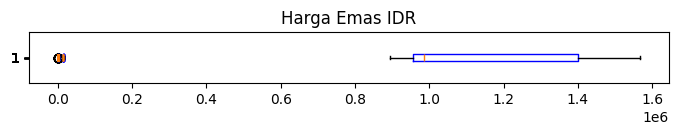

In [ ]:
#melakukan perhitungan jumlah kolom numerik
num_plots = len(numerical_cols)
num_rows = (num_plots - 1) // 3 + 1
num_cols = min(num_plots, 3)

#visualisasi boxplot unutk semua kolom numerik
plt.figure(figsize=(20,14))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(num_rows, num_cols, 1)
    plt.boxplot(outliers_data[column], vert=False, boxprops=dict(color='blue'))
    plt.title(column)

#menampilkan hasil visualisasi
plt.tight_layout()
plt.show()

Insight: dari visualisasi data harga emas idr didapatkan bahwa terdapat outlier pada data tersebut, namun outlier pada data ini tidak ditangani karena merupakan salah satu informasi yang bermanfaat.

**C. Visualisasi Heatmap Untuk Melihat Korelasi Antar Variabel**

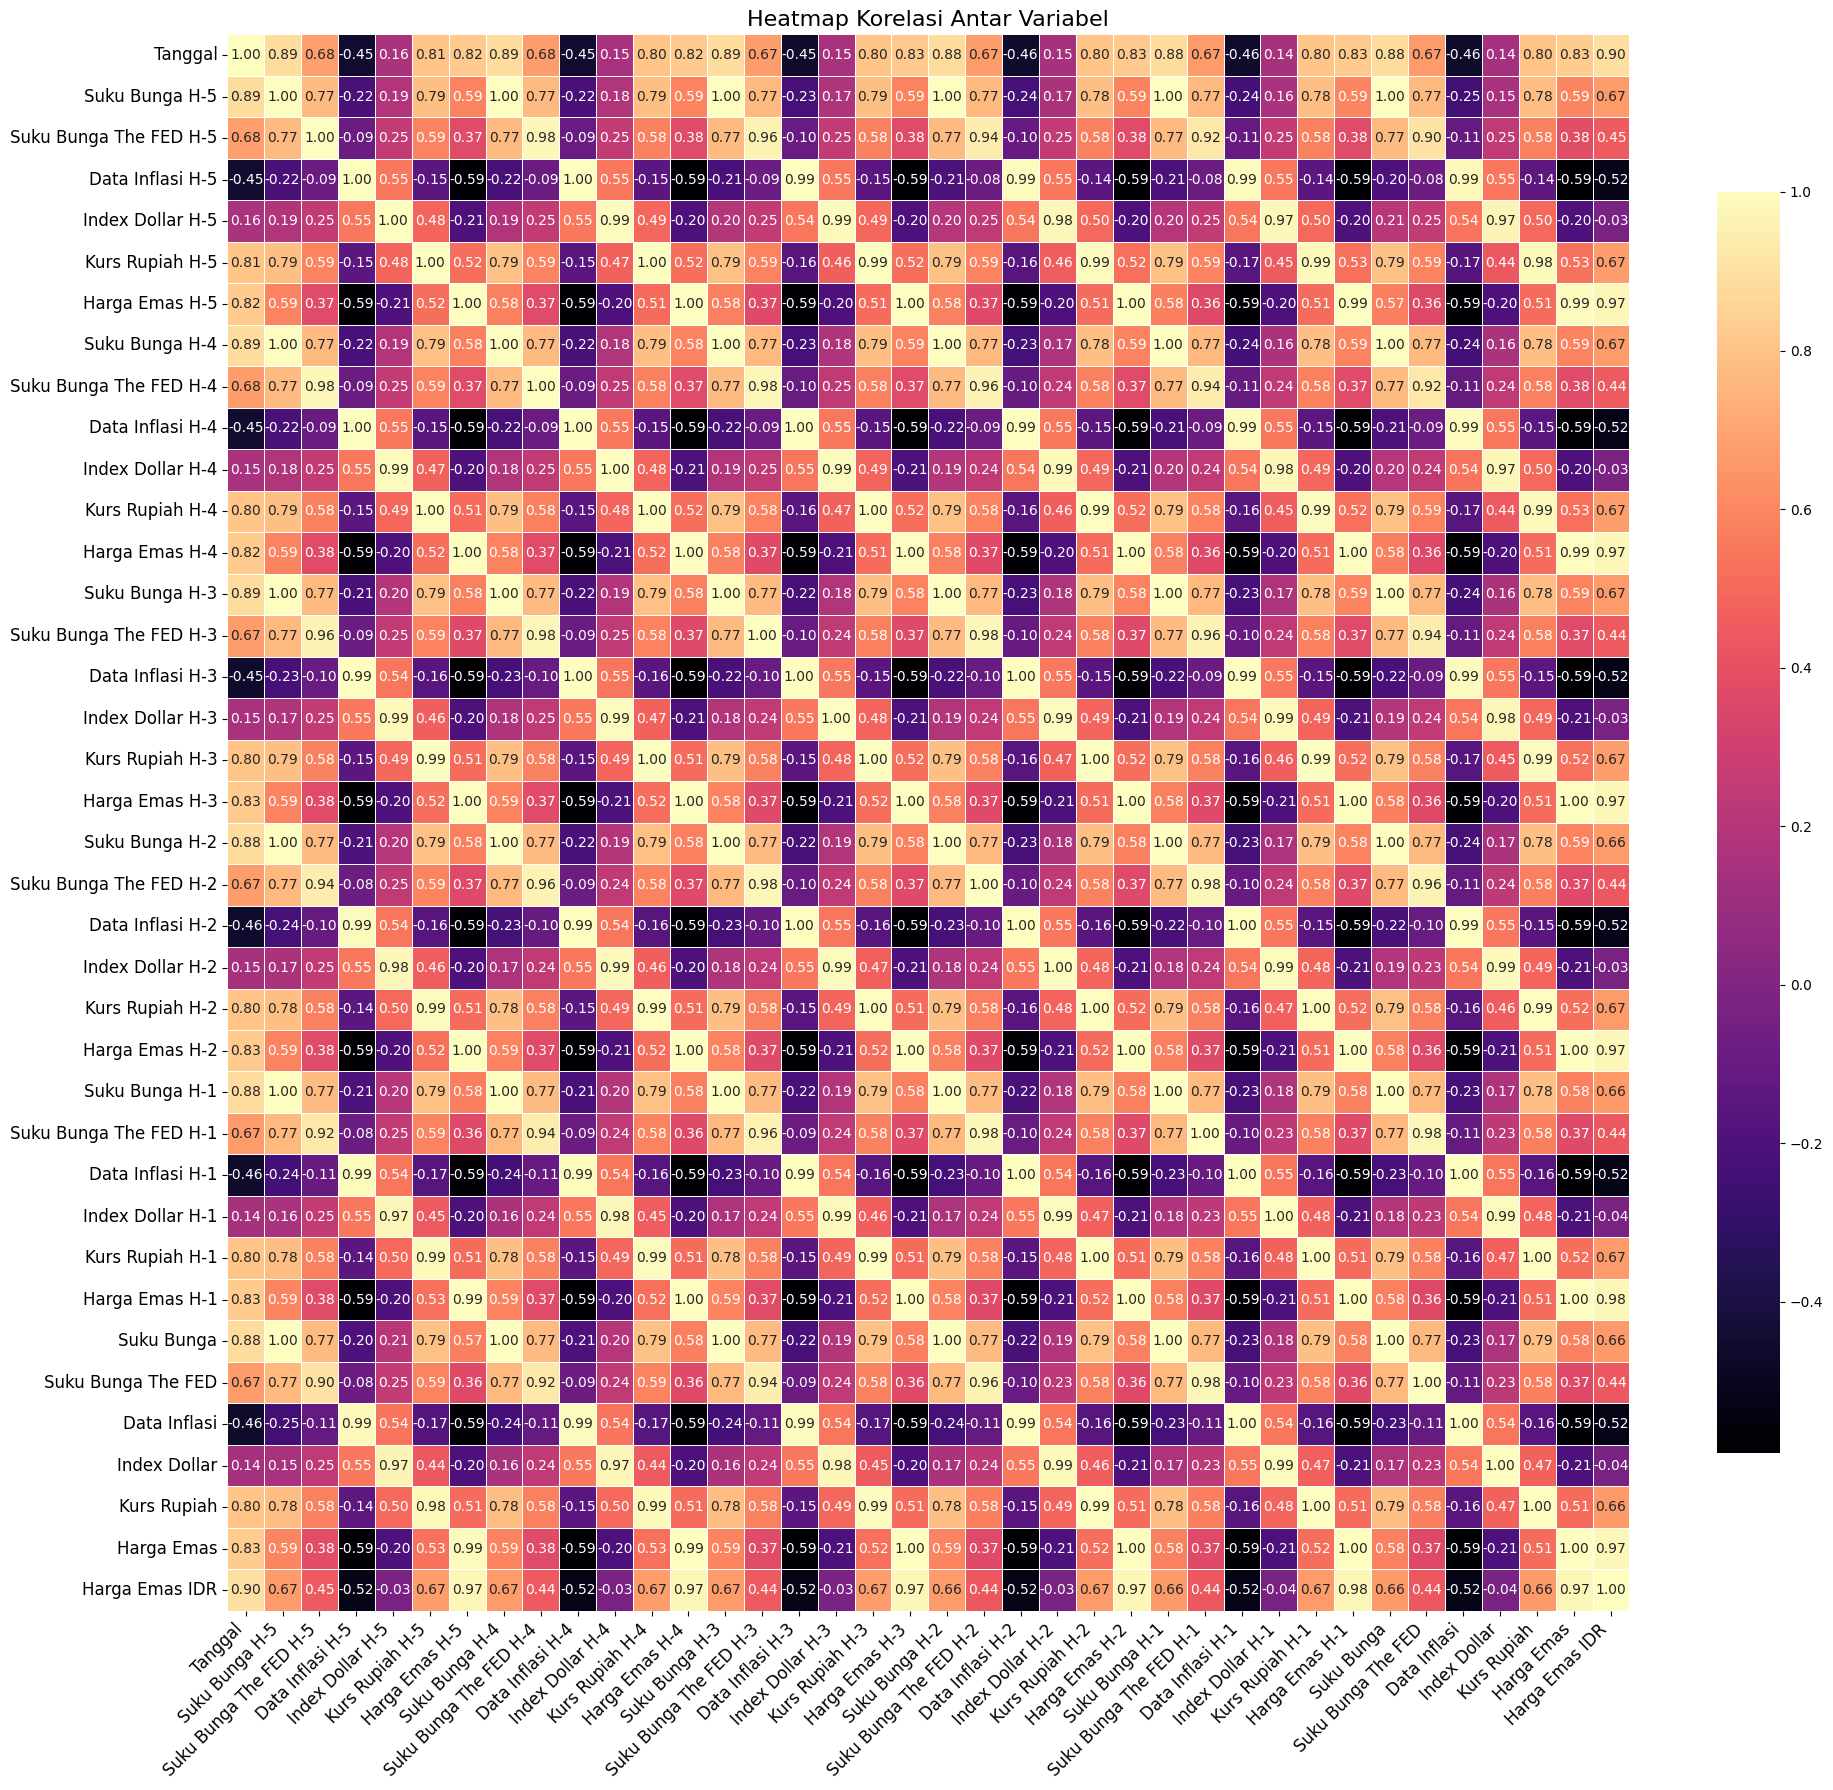

In [ ]:
#menghitung korelasi antar kolom dalam dataframe data
correlation_matrix = data.corr()

#membuat plot heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})

#menyesuaikan rotasi label untuk mencegah tumpang tindih
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

#memberikan judul pada heatmap
plt.title("Heatmap Korelasi Antar Variabel", fontsize=16)
plt.tight_layout()  #

#menampilkan heatmap
plt.show()

Insight: visualisasi heatmap digunakan untuk mengetahui korelasi antara satu variabel dengan variabel lainnya. Semakin tinggi nilai korelasi (mendekati angka 1) maka data semakin berhubungan erat dengan data lainnya dan sebaliknya atau dapat dikatakan bahwa apabila variabel a dan b berkorelasi positif maka apabila variabel a naik maka variabel b juga akan naik.

**D. Visualisasi Tren Waktu**

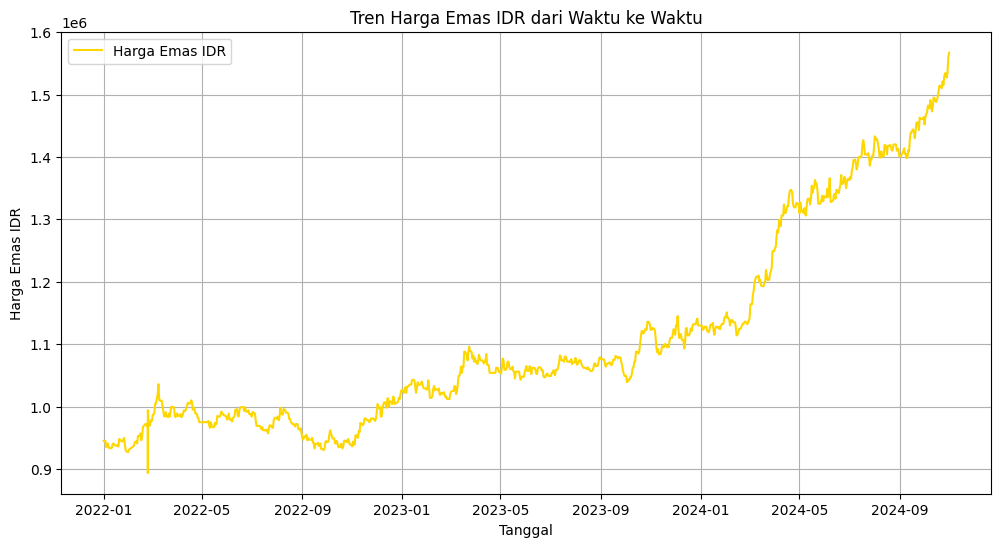

In [ ]:
# Plot tren harga emas IDR dari waktu ke waktu
plt.figure(figsize=(12, 6))
plt.plot(data['Tanggal'], data['Harga Emas IDR'], label='Harga Emas IDR', color='gold')
plt.title('Tren Harga Emas IDR dari Waktu ke Waktu')
plt.xlabel('Tanggal')
plt.ylabel('Harga Emas IDR')
plt.legend()
plt.grid(True)
plt.show()

Insight: Visualisasi tren waktu di atas didapatkan bahwa harga emas mengalami kenaikan yang signifikan dari tahun 2022 hingga 2024. Grafik tersebut menunjukkan adanya penurunan pada pertengahan tahun 2022 dan terdapat kenaikan yang lumayan tinggi pada awal tahun 2024.

**E. Scatter Plot Kolom dengan Harga Emas IDR**

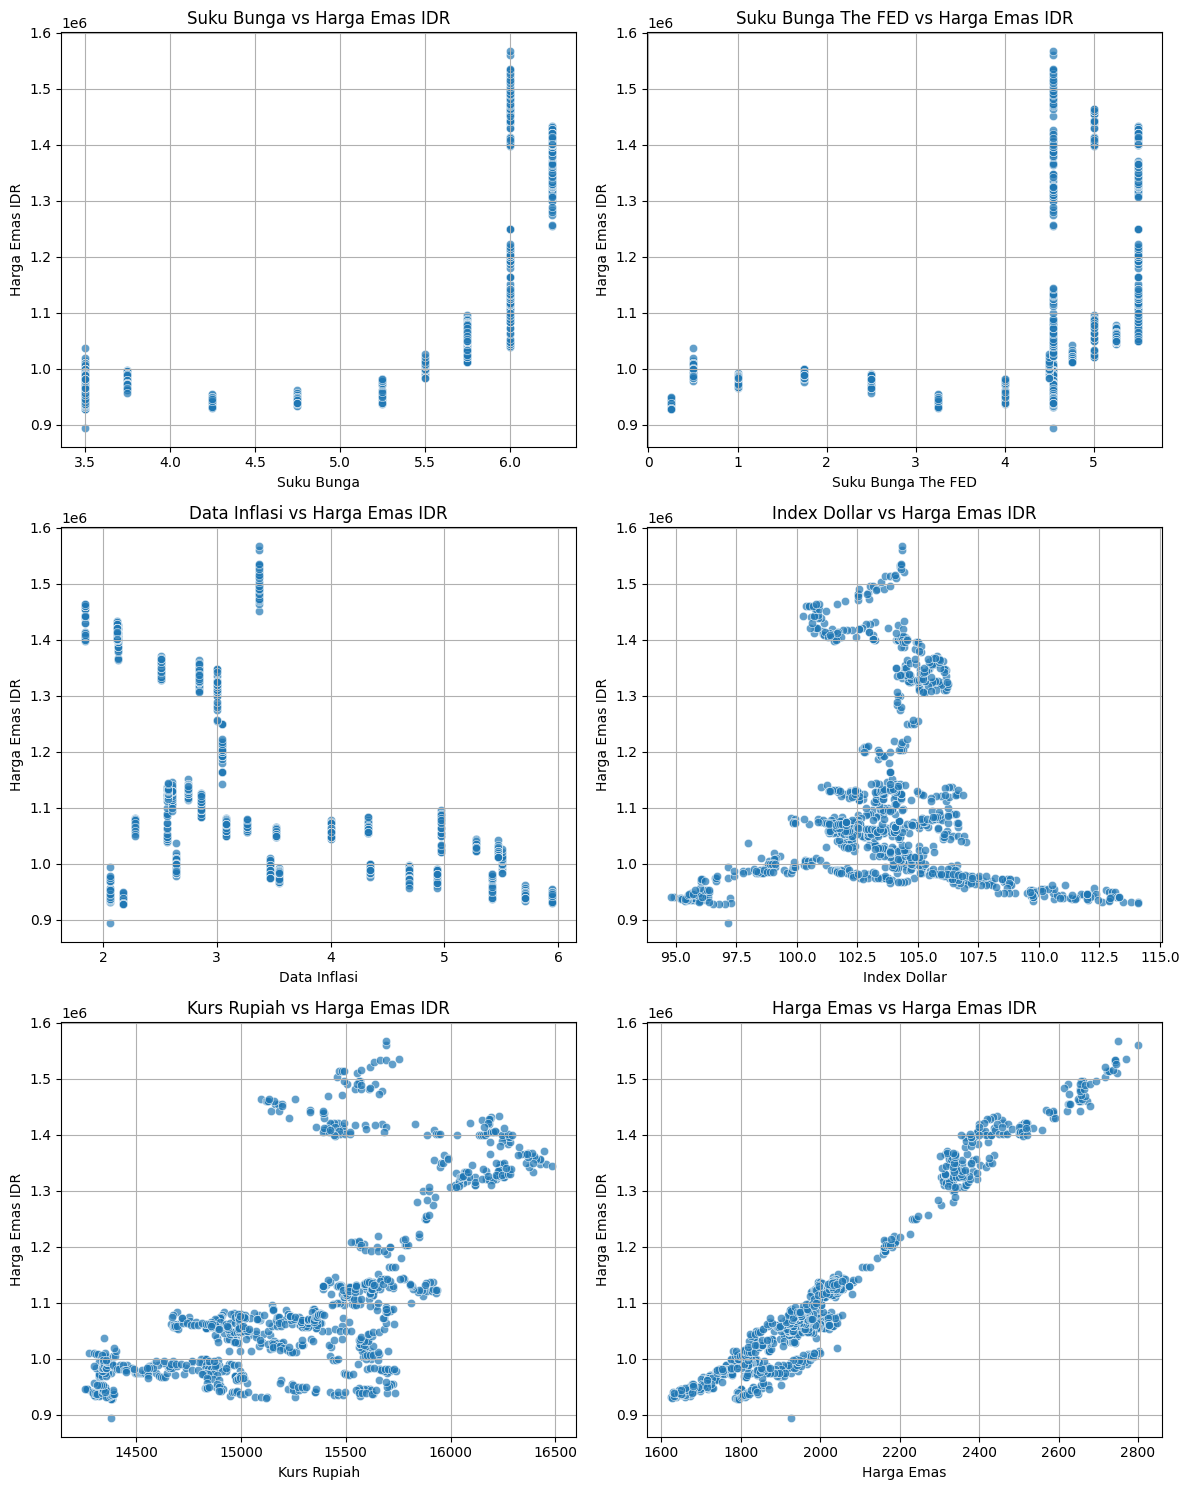

In [ ]:
#memilih kolom yang akan divisualisasi
target_col = 'Harga Emas IDR'
other_columns = ['Suku Bunga', 'Suku Bunga The FED', 'Data Inflasi', 'Index Dollar', 'Kurs Rupiah', 'Harga Emas']

ncols = 2
nrows = math.ceil(len(other_columns) / ncols)

#memuat subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5 * nrows))

axes = axes.flatten()

#looping untuk membuat scatter plot di setiap subplot
for i, col in enumerate(other_columns):
    sns.scatterplot(x=data[col], y=data[target_col], alpha=0.7, ax=axes[i])
    axes[i].set_title(f'{col} vs {target_col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].grid(True)

for j in range(len(other_columns), len(axes)):
    fig.delaxes(axes[j])

#manampilkan hasil visualisasi
plt.tight_layout()
plt.show()

Insight: Visualisasi di atas menunjukkan hubungan antar variabel terhadap harga emas idr, grafik di atas menunjukkan bahwa suku bunga dan inflasi berpengaruh positif terhadap harga emas.

**F. Visualisasi Perubahan Harga Emas**

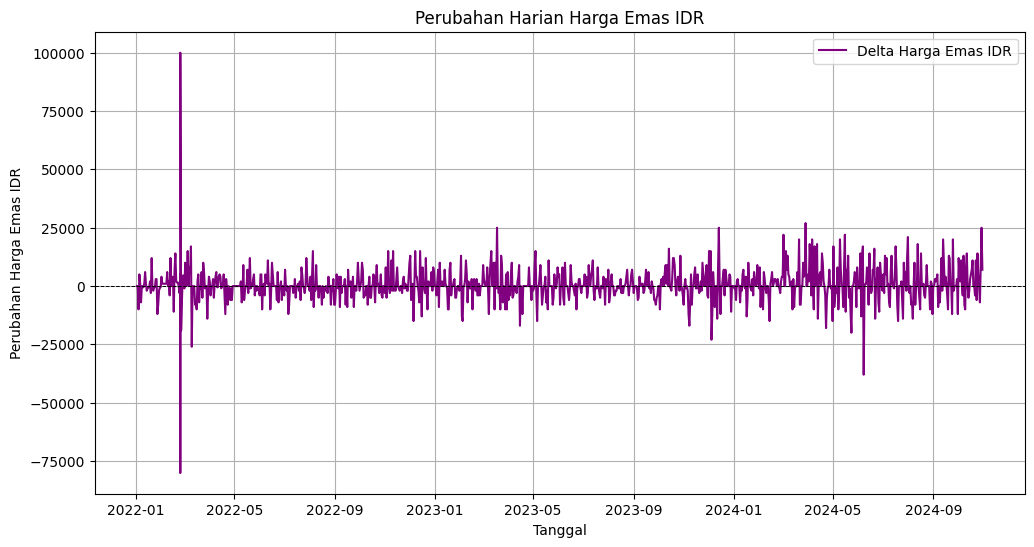

In [ ]:
# Hitung perubahan harian (delta)
data['Delta Harga Emas IDR'] = data['Harga Emas IDR'].diff()

# Plot delta harga emas IDR
plt.figure(figsize=(12, 6))
plt.plot(data['Tanggal'], data['Delta Harga Emas IDR'], label='Delta Harga Emas IDR', color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
plt.title('Perubahan Harian Harga Emas IDR')
plt.xlabel('Tanggal')
plt.ylabel('Perubahan Harga Emas IDR')
plt.legend()
plt.grid(True)
plt.show()

Insight: Grafik di atas ini menunjukkan perubahan harian terhadap harga emas seperti kenaikan dan penurunan harga emas. Dari grafik didapatkan adanya kenaikan dan penurunan yang sangat drastis yakni kenaikan ±100.000 dan penururnan sebesar ±75.000.

# **5. Modeling**

**A. Pemilihan Fiture, Target, dan Normalisasi Data**

In [ ]:
#pemilihan fitur dan target
features = ['Suku Bunga H-1', 'Suku Bunga The FED H-1', 'Data Inflasi H-1', 'Index Dollar H-1', 'Kurs Rupiah H-1', 'Harga Emas H-1',
            'Suku Bunga H-2', 'Suku Bunga The FED H-2', 'Data Inflasi H-2', 'Index Dollar H-2', 'Kurs Rupiah H-2', 'Harga Emas H-2',
            'Suku Bunga H-3', 'Suku Bunga The FED H-3', 'Data Inflasi H-3', 'Index Dollar H-3', 'Kurs Rupiah H-3', 'Harga Emas H-3',
            'Suku Bunga H-4', 'Suku Bunga The FED H-4', 'Data Inflasi H-4', 'Index Dollar H-4', 'Kurs Rupiah H-4', 'Harga Emas H-4',
            'Suku Bunga H-5', 'Suku Bunga The FED H-5', 'Data Inflasi H-5', 'Index Dollar H-5', 'Kurs Rupiah H-5', 'Harga Emas H-5']
target = ['Harga Emas IDR']

#menyiapkan data input dan target
X = data[features].values
y = data[target].values

#normalisasi data menggunakan MinMaxScaler
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

**B. Data Spliting**

In [ ]:
#membagi data menjadi pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)

#reshaping input untuk LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

**C. Membangun dan Melatih Model LSTM + GRU**

In [ ]:
model = Sequential()

#LSTM layer
model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

#GRU layer
model.add(GRU(units=50))
model.add(Dropout(0.2))

#Output layer
model.add(Dense(1))

#kompilasi model
model.compile(optimizer='adam', loss='mean_squared_error')

#ringkasan model
model.summary()

#melatih model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 100)              │          52,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 100)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 50)                  │          22,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 75,251 (293.95 KB)

 Trainable params: 75,251 (293.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.0297 - val_loss: 0.2032
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041 - val_loss: 0.1347
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_loss: 0.1014
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 0.0831
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019 - val_loss: 0.0809
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019 - val_loss: 0.0472
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0305
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 0.0273
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 0.0235
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0137
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0156
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_

In [ ]:
#prediksi
y_pred = model.predict(X_test)

#membalikkan normalisasi hasil prediksi dan data asli
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test)

#menghitung MSE dan RMSE
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

#menghitung MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)

#menampilkan hasil evaluasi
print(f"MAE: {mae:,.2f} IDR")
print(f"Mean Absolute Percentage Error (MAPE): {mape} %")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f} IDR")
print(f"R-squared (R²): {r2:.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f} IDR")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
MAE: 42,259.93 IDR
Mean Absolute Percentage Error (MAPE): 2.965468201958623 %
Root Mean Squared Error (RMSE): 49,185.52 IDR
R-squared (R²): 0.37
Mean Squared Error (MSE): 2,419,215,612.52 IDR


**D. Tuning Hyperparameters**

In [ ]:
#fungsi untuk membangun model
def build_model(hp):
    model = Sequential()

    #LSTM Layer
    model.add(LSTM(units=hp.Int('lstm_units', min_value=50, max_value=200, step=50),
                   return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(hp.Float('lstm_dropout', min_value=0.1, max_value=0.5, step=0.1)))

    #GRU Layer
    model.add(GRU(units=hp.Int('gru_units', min_value=50, max_value=200, step=50)))
    model.add(Dropout(hp.Float('gru_dropout', min_value=0.1, max_value=0.5, step=0.1)))

    #Output Layer
    model.add(Dense(1))

    #Optimizer
    optimizer = Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4]))
    model.compile(optimizer=optimizer, loss='mean_squared_error')

    return model

#Inisialisasi Keras Tuner
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,  # Jumlah kombinasi yang diuji
    executions_per_trial=1,  # Pelatihan ulang setiap kombinasi
    directory='my_dir',
    project_name='lstm_gru_tuning'
)

#Mencari hyperparameter terbaik
tuner.search(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

#Hyperparameter terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters: {best_hps.values}")

Reloading Tuner from my_dir/lstm_gru_tuning/tuner0.json
Best Hyperparameters: {'lstm_units': 150, 'lstm_dropout': 0.2, 'gru_units': 50, 'gru_dropout': 0.4, 'learning_rate': 0.01}


**E. Membangun Ulang Model Setelah Tuning**

In [ ]:
model = Sequential()

#LSTM layer
model.add(LSTM(units=150, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))) #ubah units dan dropout sesuai dengan best parameters
model.add(Dropout(0.2))

#GRU layer
model.add(GRU(units=50)) #ubah units dan dropout sesuai dengan best parameters
model.add(Dropout(0.4))

#Output layer
model.add(Dense(1))

#membuat optimizer Adam dengan learning rate yang disesuaikan
optimizer = Adam(learning_rate=0.01)

#kompilasi model dengan optimizer yang disesuaikan
model.compile(optimizer=optimizer, loss='mean_squared_error')

#ringkasan model
model.summary()

#melatih model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 1, 150)              │         108,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 50)                  │          30,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 138,951 (542.78 KB)

 Trainable params: 138,951 (542.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0537 - val_loss: 0.1565
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 - val_loss: 0.0997
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - val_loss: 0.0740
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - val_loss: 0.0721
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0443
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0018 - val_loss: 0.0215
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 0.0157
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 0.0064
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.1425e-04 - val_loss: 0.0152
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.8401e-04 - val_loss: 0.0047
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012 - val_loss: 0.0028
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.6563

**D. Evaluasi dan Akurasi Model**

In [ ]:
#prediksi
y_pred = model.predict(X_test)

#membalikkan normalisasi hasil prediksi dan data asli
y_train_rescaled = scaler_y.inverse_transform(y_train)
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_test_rescaled = scaler_y.inverse_transform(y_test)

#menghitung MSE dan RMSE
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

#menghitung MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)

#menampilkan hasil evaluasi
print(f"MAE: {mae:,.2f} IDR")
print(f"Mean Absolute Percentage Error (MAPE): {mape} %")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f} IDR")
print(f"R-squared (R²): {r2:.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f} IDR")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
MAE: 17,402.97 IDR
Mean Absolute Percentage Error (MAPE): 1.2538145382101744 %
Root Mean Squared Error (RMSE): 21,130.82 IDR
R-squared (R²): 0.88
Mean Squared Error (MSE): 446,511,516.22 IDR


In [ ]:
#menghitung rata-rata harga emas dan 10% dari rata-rata
mean_harga = data['Harga Emas IDR'].mean()
ten_percent_harga = 0.1 * mean_harga

#menampilkan hasil
print(f"Rata-rata harga emas IDR: {mean_harga:,.2f} IDR, dan didapatkan hasil MAE = {mae:,.2f} IDR.")

#kesimpulan hasil
if mae > ten_percent_harga:
    print("Model kurang baik, karena kesalahan prediksi (MAE) lebih dari 10% rata-rata harga emas.")
else:
    print("Model memiliki hasil prediksi yang relatif baik, karena kesalahan prediksi (MAE) berada di bawah 10% rata-rata harga emas.")


Rata-rata harga emas IDR: 1,108,095.95 IDR, dan didapatkan hasil MAE = 17,402.97 IDR.
Model memiliki hasil prediksi yang relatif baik, karena kesalahan prediksi (MAE) berada di bawah 10% rata-rata harga emas.


# **6. Results**

**A. Visualisasi Hasil Modeling**

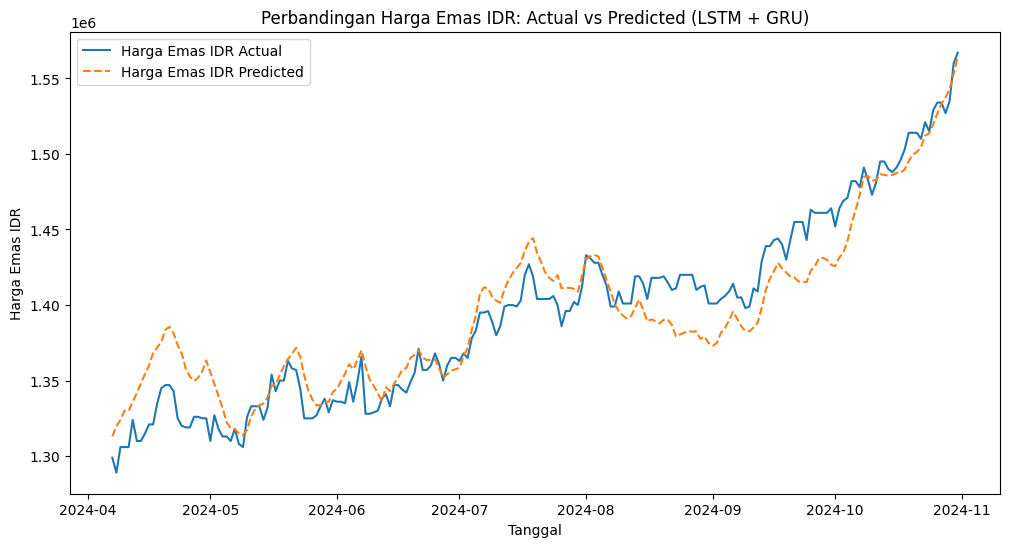

In [ ]:
#visualisasi perbandingan antara data asli dan prediksi
plt.figure(figsize=(12,6))
plt.plot(data['Tanggal'][-len(y_test):], y_test_rescaled, label='Harga Emas IDR Actual')
plt.plot(data['Tanggal'][-len(y_pred):], y_pred_rescaled, label='Harga Emas IDR Predicted', linestyle='--')
plt.title('Perbandingan Harga Emas IDR: Actual vs Predicted (LSTM + GRU)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Emas IDR')
plt.legend()
plt.show()

**B. Visualiasai Performa Model**

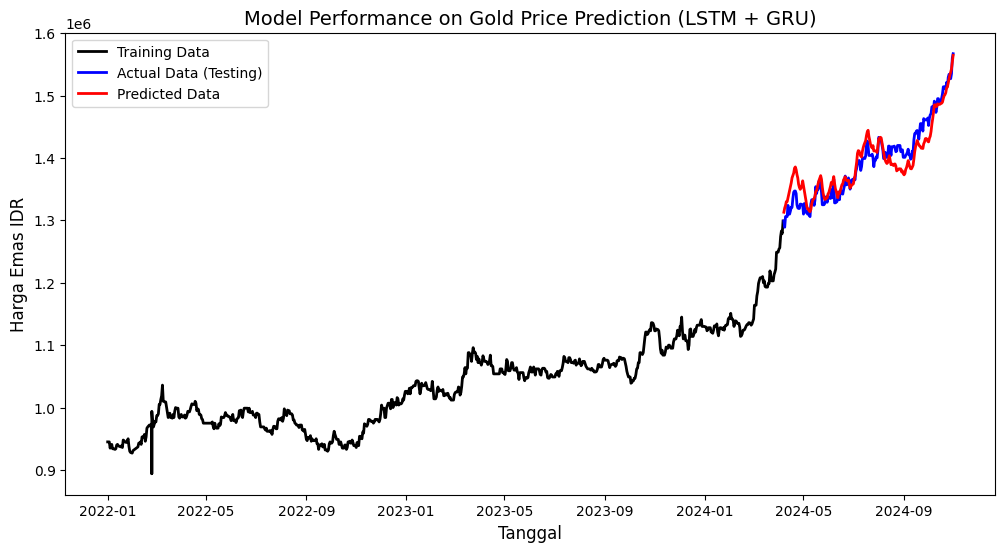

In [ ]:
plt.figure(figsize=(12, 6))

# Data pelatihan
plt.plot(data['Tanggal'][:len(y_train)], scaler_y.inverse_transform(y_train).ravel(), color='black', lw=2, label='Training Data')

# Data aktual (y_test)
plt.plot(data['Tanggal'][len(y_train):len(y_train) + len(y_test)], y_test_rescaled.ravel(), color='blue', lw=2, label='Actual Data (Testing)')

# Data prediksi (y_pred)
plt.plot(data['Tanggal'][len(y_train):len(y_train) + len(y_pred)], y_pred_rescaled.ravel(), color='red', lw=2, label='Predicted Data')

# Estetika plot
plt.title('Model Performance on Gold Price Prediction (LSTM + GRU)', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Emas IDR', fontsize=12)
plt.legend()
plt.show()

**C. Hasil Prediksi**

In [ ]:
#mengambil data input terakhir (hari terbaru yang tersedia)
last_data = X_scaled[-1].reshape(1, 1, X_scaled.shape[1])

#membuat prediksi untuk hari berikutnya
next_day_prediction_scaled = model.predict(last_data)

#membalikkan normalisasi hasil prediksi
next_day_prediction = scaler_y.inverse_transform(next_day_prediction_scaled)

#menampilkan hasil prediksi
print(f"Prediksi Harga Emas untuk Hari Berikutnya (1 November 2024): IDR {next_day_prediction[0, 0]:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Prediksi Harga Emas untuk Hari Berikutnya (1 November 2024): IDR 1,564,393.50


# **7. Model Comparison**

**LSTM Modeling**

In [ ]:
#fitur historis dan target
features = ['Suku Bunga H-1', 'Suku Bunga The FED H-1', 'Data Inflasi H-1', 'Index Dollar H-1', 'Kurs Rupiah H-1', 'Harga Emas H-1',
            'Suku Bunga H-2', 'Suku Bunga The FED H-2', 'Data Inflasi H-2', 'Index Dollar H-2', 'Kurs Rupiah H-2', 'Harga Emas H-2',
            'Suku Bunga H-3', 'Suku Bunga The FED H-3', 'Data Inflasi H-3', 'Index Dollar H-3', 'Kurs Rupiah H-3', 'Harga Emas H-3',
            'Suku Bunga H-4', 'Suku Bunga The FED H-4', 'Data Inflasi H-4', 'Index Dollar H-4', 'Kurs Rupiah H-4', 'Harga Emas H-4',
            'Suku Bunga H-5', 'Suku Bunga The FED H-5', 'Data Inflasi H-5', 'Index Dollar H-5', 'Kurs Rupiah H-5', 'Harga Emas H-5']
target = ['Harga Emas IDR']

# Fitur (X) dan target (y)
X = data[features].values
y = data[target].values

#normalisasi data menggunakan MinMaxScaler
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

#membagi data menjadi pelatihan, validasi, dan pengujian
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.3, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

#reshaping input untuk LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
#membangun model LSTM
lstm_model = Sequential([
    LSTM(100, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

#kompilasi model
lstm_model.compile(optimizer='adam', loss='mse')

#pelatihan model
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0340 - val_loss: 0.0422
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0034 - val_loss: 0.0267
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020 - val_loss: 0.0235
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 0.0262
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0010 - val_loss: 0.0251
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0010 - val_loss: 0.0228
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.4319e-04 - val_loss: 0.0211
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0486e-04 - val_loss: 0.0208
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.3392e-04 - val_loss: 0.0204
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.8383e-04 - val_loss: 0.0198
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.9344e-04 - val_loss: 0.0156
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/s

In [ ]:
#prediksi menggunakan model LSTM
y_pred_lstm = lstm_model.predict(X_test)

#membalikkan normalisasi hasil prediksi dan data asli
y_pred_rescaled_lstm = scaler_y.inverse_transform(y_pred_lstm)
y_test_rescaled_lstm = scaler_y.inverse_transform(y_test)

#fungsi perhitungan MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

#menghitung metrik evaluasi
mae_lstm = mean_absolute_error(y_test_rescaled_lstm, y_pred_rescaled_lstm)
mse_lstm = mean_squared_error(y_test_rescaled_lstm, y_pred_rescaled_lstm)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_test_rescaled_lstm, y_pred_rescaled_lstm)
mape_lstm = mean_absolute_percentage_error(y_test_rescaled_lstm, y_pred_rescaled_lstm)

#menampilkan hasil evaluasi
print("Evaluasi Model LSTM")
print(f"MAE: {mae_lstm:,.2f} IDR")
print(f"MAPE: {mape_lstm:.2f} %")
print(f"RMSE: {rmse_lstm:,.2f} IDR")
print(f"R-squared (R²): {r2_lstm:.2f}")
print(f"MSE: {mse_lstm:,.2f} IDR")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Evaluasi Model LSTM
MAE: 121,016.30 IDR
MAPE: 8.47 %
RMSE: 124,655.32 IDR
R-squared (R²): -4.25
MSE: 15,538,949,474.56 IDR


**XGBoost Modeling**

In [ ]:
#ambil atau gunakan data sebelum reshaping untuk LSTM
X_train_scaled = X_train.reshape(X_train.shape[0], X_train.shape[2])
X_test_scaled = X_test.reshape(X_test.shape[0], X_test.shape[2])

#membuat model XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6)

#meatih model menggunakan data dua dimensi
xgb_model.fit(X_train_scaled, y_train.ravel())  #.ravel() mengubah y_train menjadi 1D

#prediksi menggunakan model XGBoost
y_pred_xgb = xgb_model.predict(X_test_scaled)

#membalikkan normalisasi hasil prediksi dan data asli
y_pred_rescaled_xgb = scaler_y.inverse_transform(y_pred_xgb.reshape(-1, 1))
y_test_rescaled_xgb = scaler_y.inverse_transform(y_test)

#melakukan perhitungan metrik evaluasi
mae_xgb = mean_absolute_error(y_test_rescaled_xgb, y_pred_rescaled_xgb)
mse_xgb = mean_squared_error(y_test_rescaled_xgb, y_pred_rescaled_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test_rescaled_xgb, y_pred_rescaled_xgb)
mape_xgb = mean_absolute_percentage_error(y_test_rescaled_xgb, y_pred_rescaled_xgb)

#menampilkan hasil evaluasi
print("Evaluasi Model XGBoost")
print(f"MAE: {mae_xgb:,.2f} IDR")
print(f"MAPE: {mape_xgb:.2f} %")
print(f"RMSE: {rmse_xgb:,.2f} IDR")
print(f"R-squared (R²): {r2_xgb:.2f}")
print(f"MSE: {mse_xgb:,.2f} IDR")

Evaluasi Model XGBoost
MAE: 280,044.67 IDR
MAPE: 19.64 %
RMSE: 285,647.11 IDR
R-squared (R²): -26.58
MSE: 81,594,273,561.90 IDR
